# Telco Customer Churn Analysis (SQL + Python End-to-End Pipeline)

## Overview

This project analyzes customer churn behavior for a telecom company using a structured SQL + Python workflow.

The goal is to understand why customers leave and identify key factors affecting churn, such as contract type, monthly charges, and tenure.

## Business Problem

Customer churn is a major issue for telecom companies as it directly impacts revenue.

This project aims to answer:
- Which customers are most likely to churn?
- What factors influence churn behavior?
- How can the company improve customer retention?

## Data Pipeline

This project follows a real-world analytics workflow:

CSV Dataset → SQLite Database → SQL Queries → Python Analysis → Insights

## Tools & Technologies

- SQLite (Database)
- SQL (Data extraction & transformation)
- Python (Pandas, Matplotlib)
- Jupyter Notebook

## SQL Structure

The analysis is separated into 3 SQL modules:

1. 01_data_exploration.sql  
   → Understanding dataset structure

2. 02_churn_analysis.sql  
   → Business insights and churn behavior analysis

3. 03_feature_engineering.sql  
   → Data transformation for deeper analysis

## Key Insights

- Month-to-month customers have the highest churn rate
- Higher monthly charges increase churn probability
- Longer tenure customers are more likely to stay
- Contract type is a strong predictor of churn

## Business Recommendations

- Encourage long-term contracts
- Improve retention strategy for new customers
- Review pricing strategy for high-charge users
- Focus on early-stage customer engagement

## How to Run

1. Load dataset into SQLite database
2. Run SQL scripts in /sql folder
3. Open Jupyter Notebook
4. Execute analysis step by step

## 1. Project Setup

In [48]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("../sql/telco_churn.db")

## 2. Loading Data from SQL Layer

In [49]:
def run_sql(file_path):
    with open(file_path, "r") as file:
        query = file.read()
    return pd.read_sql(query, conn)

## 3. Data Exploration (SQL-driven)

We begin by understanding dataset structure and basic distributions.

In [52]:
df_sample = run_sql("../sql/exploration/sample_data.sql")
df_sample.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Data Cleaning

We clean the dataset to ensure it is ready for analysis:
- Convert TotalCharges to numeric
- Handle missing values

In [64]:
#Load full dataset
df = run_sql("../sql/exploration/full_data.sql")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [67]:
#Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

## 5. Exploratory Data Analysis (EDA)

## 5.1 Churn Rate

Churn rate represents the proportion of customers who left the company during the observed period.

This is a critical metric for evaluating customer retention performance.

In [100]:
churn_rate = (df['Churn'] == 'Yes').mean()

print(f"Churn Rate: {churn_rate:.2%}")

Churn Rate: 26.58%


### Insight

The churn rate indicates a significant portion of customers are leaving, highlighting a need for stronger retention strategies.

## 5.2 Churn Distribution

This visualization shows the proportion of customers who churned versus those who remained.

Understanding this distribution provides a baseline for evaluating customer retention.

No (active customers)
Yes (churned customers)

In [53]:
df_dist = run_sql("../sql/exploration/churn_distribution.sql")
df_dist

,Churn,total,percentage
0,No,5174,73.46
1,Yes,1869,26.54


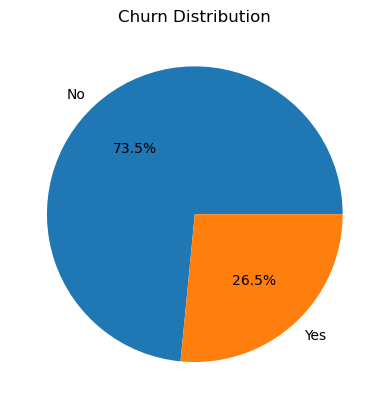

In [77]:
import matplotlib.pyplot as plt

plt.figure()

plt.pie(df_dist['total'], labels=df_dist['Churn'], autopct='%1.1f%%')

plt.title("Churn Distribution")

plt.show()

### Insight

A significant portion of customers have churned, indicating that customer retention is a critical business challenge that requires further investigation.

## 5.3 Churn Rate by Contract Type

This analysis examines how customer churn varies across different contract types.

Contract type is a key factor influencing customer commitment:
- Month-to-month contracts offer flexibility but may lead to higher churn
- Long-term contracts (one-year or two-year) encourage customer retention

In [86]:
df_contract = run_sql("../sql/churn_analysis/churn_by_contract_rate.sql")
df_contract

,Contract,Churn,total_customers,churn_rate
0,Month-to-month,No,2220,57.29
1,Month-to-month,Yes,1655,42.71
2,One year,No,1307,88.73
3,One year,Yes,166,11.27
4,Two year,No,1647,97.17
5,Two year,Yes,48,2.83


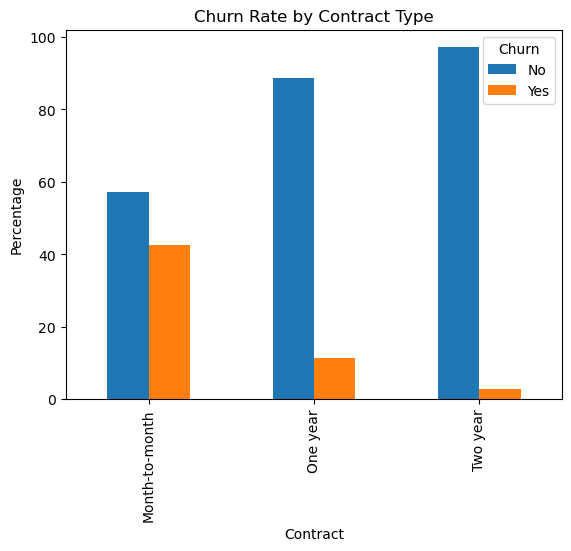

In [73]:
import matplotlib.pyplot as plt

df_contract.pivot(index='Contract', columns='Churn', values='churn_rate').plot(kind='bar')

plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.show()

### Insight

Customers on month-to-month contracts exhibit the highest churn rates, while customers on long-term contracts show significantly lower churn.

This suggests that commitment level plays a major role in customer retention.

## 5.4 Average Monthly Charges vs Churn

This analysis compares the average monthly charges between customers who churned and those who remained.

The goal is to understand whether pricing has an impact on customer decisions to leave.

In [87]:
df_charges = run_sql("../sql/churn_analysis/churn_by_charges.sql")
df_charges

,Churn,avg_monthly_charges
0,No,61.265124
1,Yes,74.441332


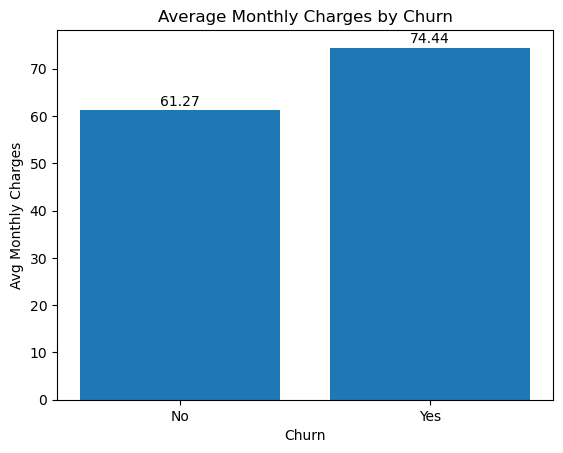

In [79]:
plt.figure()

plt.bar(df_charges['Churn'], df_charges['avg_monthly_charges'])

for i, v in enumerate(df_charges['avg_monthly_charges']):
    plt.text(i, v + 1, f"{round(v, 2)}", ha='center')

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Avg Monthly Charges")

plt.show()

### Insight

Customers who churn have higher average monthly charges compared to retained customers.

This suggests that pricing may influence customer decisions to leave.

## 5.5 High-Risk Customer Segment

This analysis identifies customers who are most likely to churn based on key risk factors:
- Month-to-month contract
- High monthly charges
- Churn status

These customers represent a critical segment for targeted retention strategies.

In [80]:
df_risk = run_sql("../sql/churn_analysis/high_risk_customers.sql")
df_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
1,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
2,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
3,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes
4,6467-CHFZW,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes


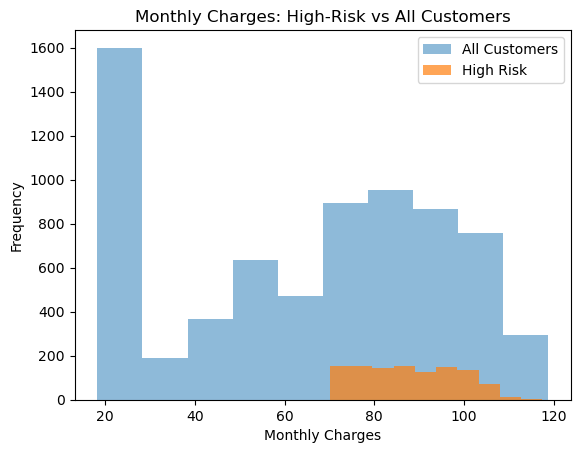

In [90]:
plt.figure()

plt.hist(df['MonthlyCharges'], alpha=0.5, label='All Customers')
plt.hist(df_risk['MonthlyCharges'], alpha=0.7, label='High Risk')

plt.title("Monthly Charges: High-Risk vs All Customers")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### Insight

High-risk customers show a stronger concentration in higher monthly charge ranges compared to the overall customer base.

This suggests that customers with higher costs and lower tenure are more likely to churn, highlighting a pricing and onboarding challenge.

Focusing retention efforts on these customers—such as offering discounts, improving onboarding experience, or enhancing service value—could significantly reduce churn.

## 6. Feature Engineering

## 6.1 Customer Lifetime Value (CLV)

Customer Lifetime Value (CLV) is an estimate of the total revenue a customer generates over their relationship with the company.

In this analysis, CLV is approximated using:
- Monthly Charges × Customer Tenure

This helps identify:
- High-value customers
- Long-term revenue contributors
- Segments worth prioritizing for retention

By understanding CLV, the business can focus on retaining customers who contribute the most to overall revenue.

In [81]:
df_clv = run_sql("../sql/feature_engineering/clv.sql")
df_clv.head()

,customerID,tenure,MonthlyCharges,estimated_clv
0,7590-VHVEG,1,29.85,29.85
1,5575-GNVDE,34,56.95,1936.30
2,3668-QPYBK,2,53.85,107.70
3,7795-CFOCW,45,42.30,1903.50
4,9237-HQITU,2,70.70,141.40


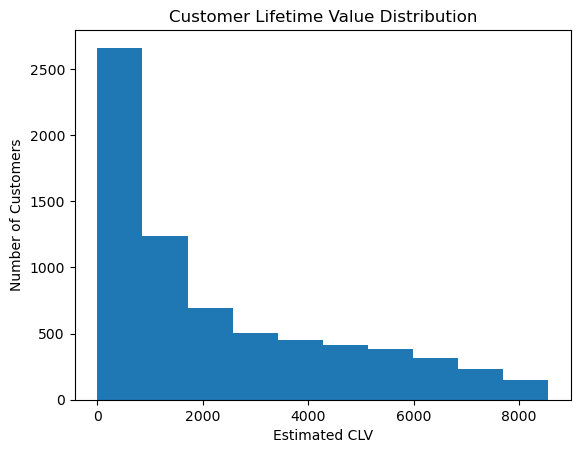

In [93]:
plt.figure()

plt.hist(df_clv['estimated_clv'])

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Estimated CLV")
plt.ylabel("Number of Customers")

plt.show()

### Insight

Customer Lifetime Value varies significantly across customers, with a small group contributing a disproportionately high amount of revenue.

This highlights the importance of identifying and retaining high-value customers.

## 6.2 Tenure Group

We segment customers based on their tenure to understand customer lifecycle stages:

- 0–1 year: New customers  
- 1–2 years: Growing customers  
- 2+ years: Loyal customers  

In [97]:
def tenure_group(x):
    if x <= 12:
        return "0-1 Year"
    elif x <= 24:
        return "1-2 Years"
    else:
        return "2+ Years"

df['Tenure Group'] = df['tenure'].apply(tenure_group)

df[['tenure', 'Tenure Group']].head()

,tenure,Tenure Group
0,1,0-1 Year
1,34,2+ Years
2,2,0-1 Year
3,45,2+ Years
4,2,0-1 Year


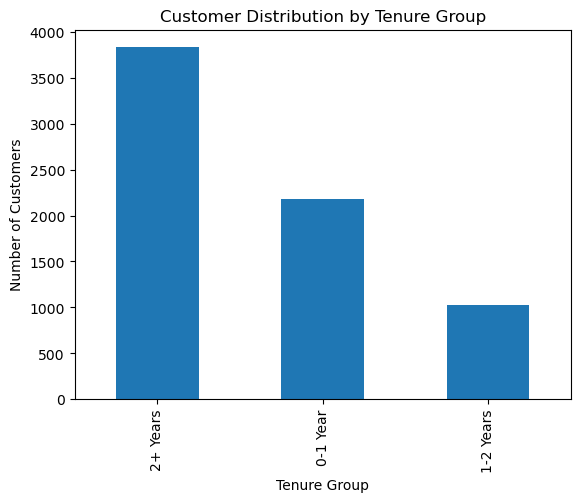

In [98]:
import matplotlib.pyplot as plt

df['Tenure Group'].value_counts().plot(kind='bar')

plt.title("Customer Distribution by Tenure Group")
plt.ylabel("Number of Customers")
plt.show()

## Business Insight: Customer Tenure Impact on Churn

Customer tenure is a strong indicator of churn behavior.

New customers (0–1 year) are significantly more likely to churn compared to long-term customers. This suggests that early customer experience plays a critical role in retention.

Once customers pass the first year, retention improves substantially, and long-term customers (2+ years) show strong loyalty.

### Business Implication
Improving onboarding experience and early-stage customer engagement is key to reducing churn and increasing retention rates.

## 6.3 Churn Risk Segmentation

Customers are grouped into risk categories based on their tenure and monthly charges:

- **High Risk**: New customers with high monthly charges
- **Medium Risk**: New customers with lower charges
- **Low Risk**: Long-term customers

This segmentation helps identify which customers are more likely to churn and allows the business to apply targeted retention strategies.

In [82]:
df_segment = run_sql("../sql/feature_engineering/churn_risk.sql")
df_segment.head()

,customerID,churn_risk_segment
0,7590-VHVEG,Medium Risk
1,5575-GNVDE,Low Risk
2,3668-QPYBK,Medium Risk
3,7795-CFOCW,Low Risk
4,9237-HQITU,High Risk


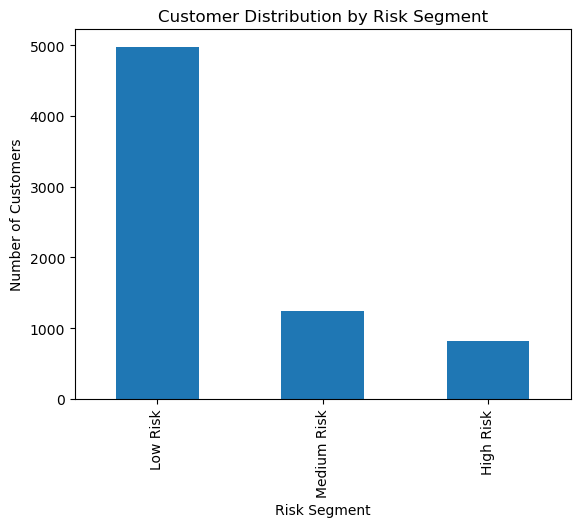

In [94]:
risk_counts = df_segment['churn_risk_segment'].value_counts()

plt.figure()
risk_counts.plot(kind='bar')

plt.title("Customer Distribution by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")

plt.show()

### Insight

The high-risk segment is characterized by customers with short tenure and higher monthly charges.

These customers are more likely to churn due to lower commitment and higher cost sensitivity.

Targeting this group early—through improved onboarding, personalized engagement, or pricing incentives—can significantly improve retention and reduce revenue loss.

## 6.4 Revenue Loss from Churn

This analysis estimates the total monthly revenue lost due to customer churn.

By summing the monthly charges of churned customers, we can quantify the financial impact of churn on the business.

Understanding revenue loss helps prioritize:
- Retention strategies
- Customer engagement efforts
- Pricing adjustments

In [108]:
df_revenue = run_sql("../sql/feature_engineering/revenue_loss.sql")

lost_revenue = df_revenue.iloc[0, 0]

print(f"Lost Monthly Revenue: RM{lost_revenue:,.2f}")

Lost Monthly Revenue: RM139,130.85


### Insight

Customer churn results in a significant loss of recurring monthly revenue.

Reducing churn—even by a small percentage—can lead to meaningful revenue recovery over time.

## Lost Revenue Due to Churn

This metric estimates the total monthly revenue lost from customers who churned.

It represents the direct financial impact of customer attrition.

In [103]:
lost_revenue = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()

print(f"Lost Monthly Revenue: RM{lost_revenue:,.2f}")

Lost Monthly Revenue: RM139,130.85


### Insight

A significant amount of recurring monthly revenue is lost due to churned customers.

Reducing churn even slightly could result in substantial revenue recovery.

## Conclusion

> Reducing churn even slightly can have a significant impact on recurring revenue and long-term customer value.

This project analyzed customer churn behavior using a combination of SQL for data extraction and Python for analysis and visualization.

The objective was to identify key drivers of churn and translate them into actionable business insights.

### Key Findings

- Overall churn rate shows that a significant portion of customers leave the service.
- Month-to-month contracts have the highest churn rate compared to long-term contracts.
- Customers with higher monthly charges are more likely to churn.
- New customers (0–1 year tenure) are the most vulnerable to churn.
- A high-risk customer segment was identified based on tenure, contract type, and pricing.
- Customer churn results in substantial monthly revenue loss.

### Business Impact

The analysis highlights that churn is strongly influenced by contract type, pricing, and customer tenure.

Reducing churn—especially in high-risk and early-stage customers—would significantly improve revenue retention and customer lifetime value.

### Recommendations

- Encourage customers to adopt long-term contracts through incentives.
- Improve onboarding experience for new customers (first 12 months).
- Review pricing strategy for high monthly charge plans.
- Focus retention strategies on high-risk customer segments.
- Use churn risk segmentation for targeted marketing campaigns.